# NFL Week 1 Analysis — Statistical Analysis

This notebook evaluates two questions:

1. **Are Week 1 games statistically different from later regular-season games?**
2. **Do Week 1 team characteristics persist throughout the season?**

The analysis uses game-level statistics for Question 2 and team-season observations for Question 3. Statistical tests are adjusted for multiple comparisons using the Benjamini–Hochberg false discovery rate procedure.


## 1. Load prepared datasets

The data-preparation notebook creates three Parquet datasets. This notebook uses:

- `games.parquet` — one row per game
- `team_stats.parquet` — one row per team per game

`team_results.parquet` is not needed here because the statistical analysis focuses on game statistics and team performance measures.


In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests
from scipy.stats import (
    ttest_ind,
    mannwhitneyu,
    pearsonr,
    spearmanr,
    t
)
import matplotlib.pyplot as plt

games = pd.read_parquet("../data/games.parquet")
team_stats = pd.read_parquet("../data/team_stats.parquet")

print("games:", games.shape)
print("team_stats:", team_stats.shape)


games: (4927, 15)
team_stats: (9854, 69)


In [3]:
# Basic data validation
assert games["game_id_normalized"].is_unique
assert team_stats[["game_id_normalized", "team"]].duplicated().sum() == 0

print("Unique games:", games["game_id_normalized"].nunique())
print("Team-game observations:", len(team_stats))
print("Week 1 games:", (games["week"] == 1).sum())
print("Week 1 team-game observations:", (team_stats["week"] == 1).sum())


Unique games: 4927
Team-game observations: 9854
Week 1 games: 303
Week 1 team-game observations: 606


# Q2. Are Week 1 games statistically different?

To avoid treating the two teams in the same game as independent observations, team-level statistics are aggregated to the **game level**.

Week 1 is then compared with Weeks 2–18 using:

- Welch's independent-samples t-test
- Mann–Whitney U test
- Difference in means
- 95% confidence interval for the difference in means
- Cohen's *d* effect size

Because 12 metrics are tested, p-values are adjusted using the Benjamini–Hochberg false discovery rate procedure.


### 2.1 Aggregate team-game statistics to the game level

Each game is represented by one row so that home and away team observations are not treated as independent games.

In [4]:
game_stats = (
    team_stats
    .groupby("game_id_normalized")
    .agg(
        total_penalties=("penalties", "sum"),
        total_penalty_yards=("penalty_yards", "sum"),
        total_fumbles_lost=(
            "fumbles_lost_total",
            "sum"
        ),
        total_interceptions=(
            "passing_interceptions",
            "sum"
        ),
        total_passing_yards=("passing_yards", "sum"),
        total_rushing_yards=("rushing_yards", "sum"),
        total_passing_attempts=("attempts", "sum"),
        total_rushing_attempts=("carries", "sum"),
        total_sacks=("sacks_suffered", "sum"),
        total_passing_first_downs=("passing_first_downs", "sum"),
        total_rushing_first_downs=("rushing_first_downs", "sum"),
    )
    .reset_index()
)

In [5]:
game_stats["total_turnovers"] = (
    game_stats["total_fumbles_lost"]
    + game_stats["total_interceptions"]
)

game_stats["total_first_downs"] = (
    game_stats["total_passing_first_downs"]
    + game_stats["total_rushing_first_downs"]
)

game_stats["yards_per_rush"] = (
    game_stats["total_rushing_yards"]
    / game_stats["total_rushing_attempts"]
)

game_stats["yards_per_pass_attempt"] = (
    game_stats["total_passing_yards"]
    / game_stats["total_passing_attempts"]
)


In [6]:
game_stats = game_stats.merge(
    games[
        [
            "game_id_normalized",
            "season",
            "week",
            "score_home",
            "score_away"
        ]
    ],
    on="game_id_normalized",
    how="left",
    validate="one_to_one"
)

game_stats["total_points"] = (
    game_stats["score_home"]
    + game_stats["score_away"]
)

game_stats["week_1"] = game_stats["week"] == 1


### 2.2 Q2 metrics and statistical tests

In [7]:
metrics = [
    "total_penalties",
    "total_penalty_yards",
    "total_turnovers",
    "total_passing_yards",
    "total_rushing_yards",
    "total_passing_attempts",
    "total_rushing_attempts",
    "total_points",
    "total_first_downs",
    "yards_per_pass_attempt",
    "yards_per_rush",
    "total_sacks"
]


In [8]:
def compare_week1(column):
    week1 = game_stats.loc[
        game_stats["week_1"],
        column
    ]

    later = game_stats.loc[
        ~game_stats["week_1"],
        column
    ]

    # Welch's t-test
    t_stat, t_p = ttest_ind(
        week1,
        later,
        equal_var=False
    )

    # Mann-Whitney U test
    u_stat, u_p = mannwhitneyu(
        week1,
        later,
        alternative="two-sided"
    )

    # Mean difference
    difference = week1.mean() - later.mean()

    # 95% confidence interval for mean difference
    n1 = len(week1)
    n2 = len(later)

    se = np.sqrt(
        week1.var(ddof=1) / n1
        + later.var(ddof=1) / n2
    )

    df = (
        (
            week1.var(ddof=1) / n1
            + later.var(ddof=1) / n2
        ) ** 2
        /
        (
            (week1.var(ddof=1) / n1) ** 2 / (n1 - 1)
            +
            (later.var(ddof=1) / n2) ** 2 / (n2 - 1)
        )
    )

    critical_value = t.ppf(
        0.975,
        df
    )

    ci_lower = difference - critical_value * se
    ci_upper = difference + critical_value * se

    # Cohen's d
    pooled_sd = np.sqrt(
        (
            (n1 - 1) * week1.var(ddof=1)
            +
            (n2 - 1) * later.var(ddof=1)
        )
        /
        (n1 + n2 - 2)
    )

    cohens_d = difference / pooled_sd

    return {
        "Metric": column,
        "Week 1 Mean": week1.mean(),
        "Later Mean": later.mean(),
        "Difference": difference,
        "CI Lower": ci_lower,
        "CI Upper": ci_upper,
        "Cohen's d": cohens_d,
        "Welch t": t_stat,
        "Welch p": t_p,
        "MW U": u_stat,
        "MW p": u_p
    }

In [9]:
results = pd.DataFrame(
    [compare_week1(metric) for metric in metrics]
)

results["Welch p adjusted"] = multipletests(
    results["Welch p"],
    method="fdr_bh"
)[1]

results["MW p adjusted"] = multipletests(
    results["MW p"],
    method="fdr_bh"
)[1]

results = results.sort_values(
    "Welch p adjusted"
).reset_index(drop=True)

results


,Metric,Week 1 Mean,Later Mean,Difference,CI Lower,CI Upper,Cohen's d,Welch t,Welch p,MW U,MW p,Welch p adjusted,MW p adjusted
0,total_rushing_yards,216.108911,229.928633,-13.819722,-20.672842,-6.966603,-0.215985,-3.966026,0.000089,623579.0,0.001335,0.001063,0.016022
1,yards_per_rush,4.056051,4.231459,-0.175408,-0.276443,-0.074374,-0.192596,-3.414612,0.000714,635685.5,0.006860,0.004285,0.028924
2,total_penalties,13.013201,12.347102,0.666099,0.180476,1.151722,0.160201,2.697891,0.007323,764792.5,0.007231,0.029293,0.028924
3,total_rushing_attempts,52.937294,53.966696,-1.029402,-1.845245,-0.213558,-0.141000,-2.481665,0.013550,650296.5,0.036051,0.036856,0.086522
4,total_penalty_yards,109.547855,103.556445,5.991410,1.153940,10.828881,0.148291,2.436161,0.015356,760579.0,0.012307,0.036856,0.036920
5,total_points,43.610561,44.985727,-1.375166,-2.971374,0.221043,-0.098464,-1.694497,0.091074,658208.5,0.077542,0.182148,0.132930
6,total_first_downs,35.260726,35.855969,-0.595243,-1.323708,0.133223,-0.095584,-1.607202,0.108931,657112.0,0.069912,0.186740,0.132930
7,total_turnovers,2.927393,2.954585,-0.027192,-0.228229,0.173845,-0.015937,-0.266044,0.790365,689901.5,0.652001,0.878290,0.869335
8,yards_per_pass_attempt,7.068032,7.090332,-0.022301,-0.174621,0.130019,-0.017905,-0.287984,0.773535,696645.0,0.871154,0.878290,0.962396
9,total_passing_attempts,68.438944,68.188365,0.250579,-1.023536,1.524694,0.022971,0.386830,0.699122,701174.5,0.978772,0.878290,0.978772


### 2.3 Q2 visualizations

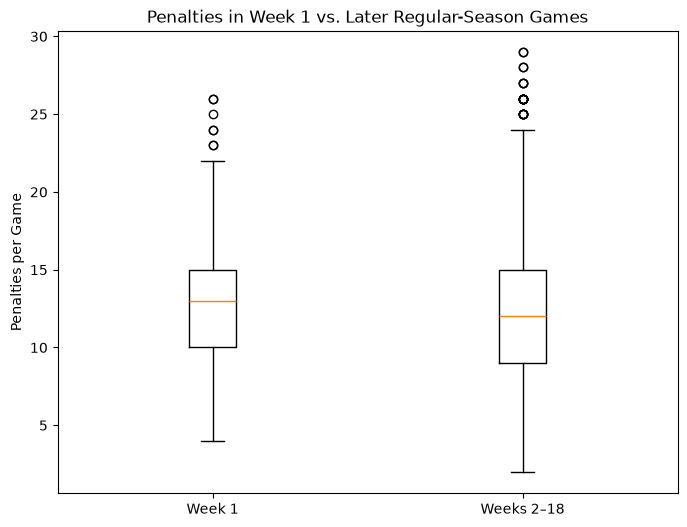

In [10]:
week1 = game_stats.loc[
    game_stats["week_1"],
    "total_penalties"
]

later = game_stats.loc[
    ~game_stats["week_1"],
    "total_penalties"
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    [week1, later],
    tick_labels=["Week 1", "Weeks 2–18"]
)

plt.ylabel("Penalties per Game")
plt.title("Penalties in Week 1 vs. Later Regular-Season Games")

plt.show()

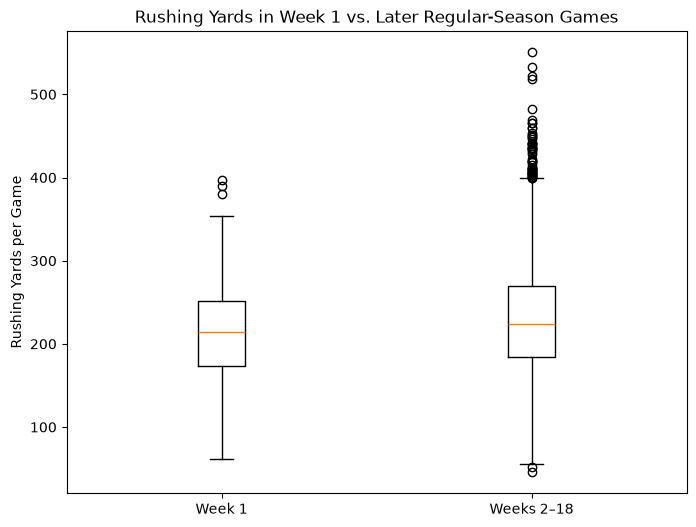

In [11]:
week1 = game_stats.loc[
    game_stats["week_1"],
    "total_rushing_yards"
]

later = game_stats.loc[
    ~game_stats["week_1"],
    "total_rushing_yards"
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    [week1, later],
    tick_labels=["Week 1", "Weeks 2–18"]
)

plt.ylabel("Rushing Yards per Game")
plt.title("Rushing Yards in Week 1 vs. Later Regular-Season Games")

plt.show()

In [12]:
week1_attempts = game_stats.loc[
    game_stats["week_1"], "total_rushing_attempts"
].mean()
later_attempts = game_stats.loc[
    ~game_stats["week_1"], "total_rushing_attempts"
].mean()

week1_ypr = game_stats.loc[
    game_stats["week_1"], "yards_per_rush"
].mean()
later_ypr = game_stats.loc[
    ~game_stats["week_1"], "yards_per_rush"
].mean()

print(f"Week 1 average rushing attempts: {week1_attempts:.2f}")
print(f"Weeks 2–18 average rushing attempts: {later_attempts:.2f}")
print(f"Week 1 average yards per rush: {week1_ypr:.2f}")
print(f"Weeks 2–18 average yards per rush: {later_ypr:.2f}")


Week 1 average rushing attempts: 52.94
Weeks 2–18 average rushing attempts: 53.97
Week 1 average yards per rush: 4.06
Weeks 2–18 average yards per rush: 4.23


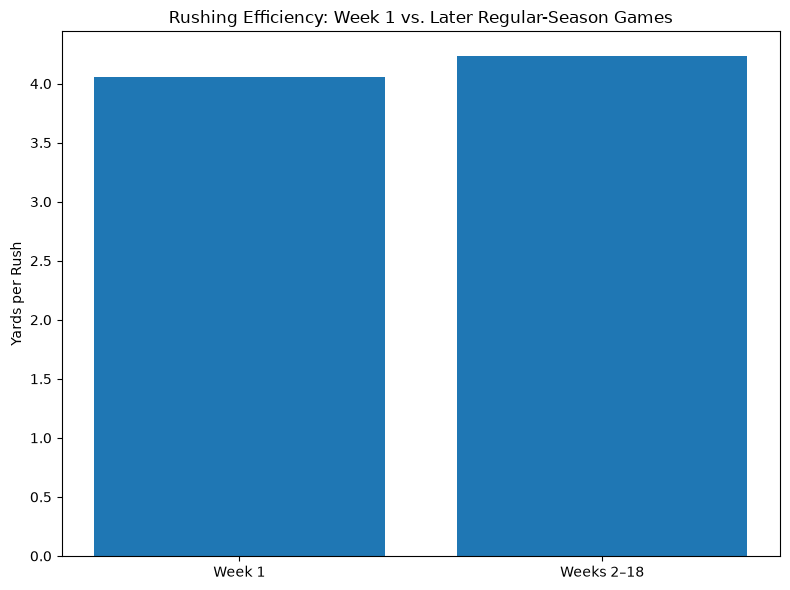

In [14]:
plt.figure(figsize=(8, 6))
plt.bar(
    ["Week 1", "Weeks 2–18"],
    [week1_ypr, later_ypr],
)
plt.ylabel("Yards per Rush")
plt.title("Rushing Efficiency: Week 1 vs. Later Regular-Season Games")
plt.tight_layout()
plt.show()


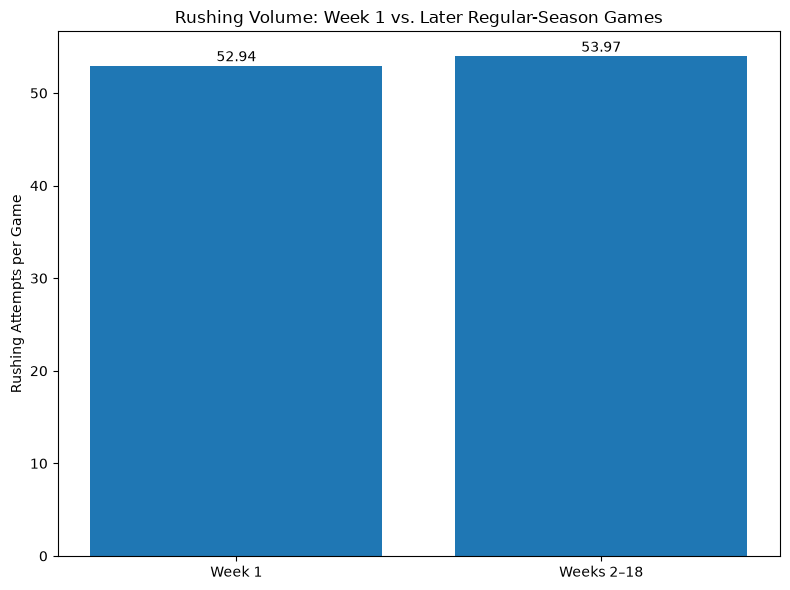

In [30]:
## 2.8 Rushing volume

periods = [
    "Week 1",
    "Weeks 2–18",
]

values = [
    week1_attempts,
    later_attempts,
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    periods,
    values,
)

plt.ylabel("Rushing Attempts per Game")
plt.title("Rushing Volume: Week 1 vs. Later Regular-Season Games")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}",
        ha="center",
    )

plt.tight_layout()
plt.show()

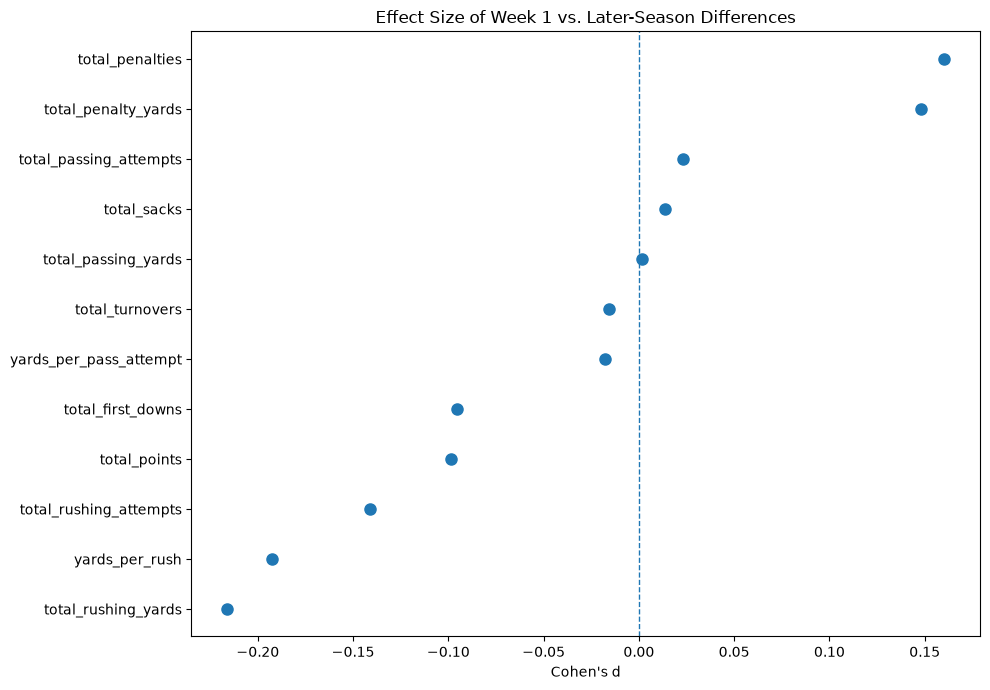

In [15]:
## 2.4 Q2 effect sizes

effect_data = (
    results
    .sort_values("Cohen's d")
    .copy()
)

plt.figure(figsize=(10, 7))

plt.errorbar(
    effect_data["Cohen's d"],
    effect_data["Metric"],
    fmt="o",
    markersize=8,
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Cohen's d")
plt.ylabel("")
plt.title("Effect Size of Week 1 vs. Later-Season Differences")

plt.tight_layout()
plt.show()

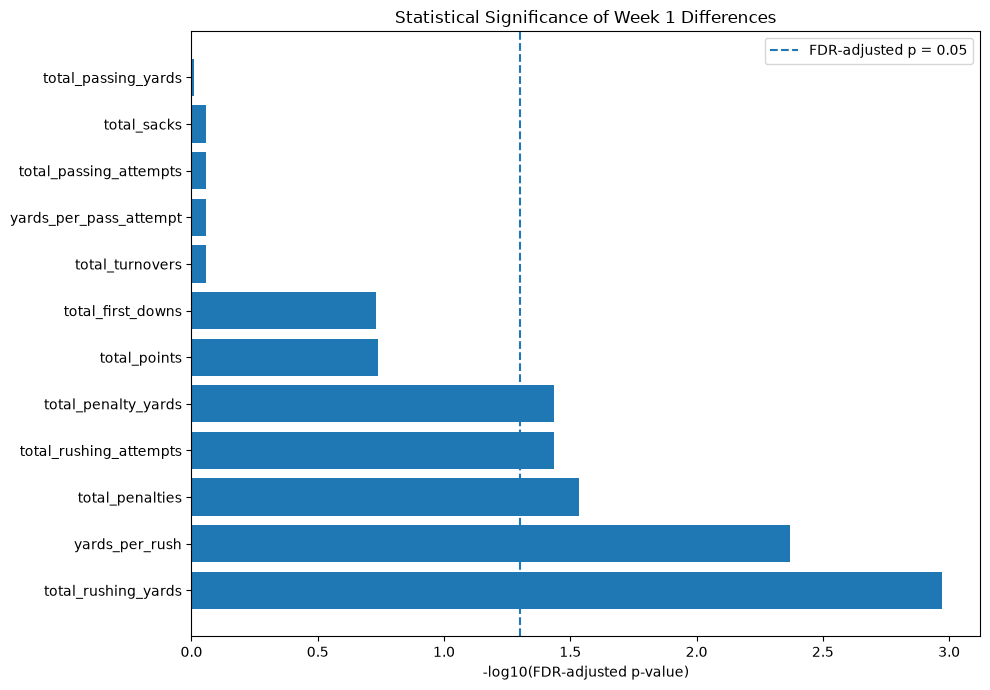

In [28]:
## 2.5 Q2 statistical significance

p_data = (
    results
    .sort_values("Welch p adjusted")
    .copy()
)

p_data["minus_log10_p"] = (
    -np.log10(p_data["Welch p adjusted"])
)

plt.figure(figsize=(10, 7))

plt.barh(
    p_data["Metric"],
    p_data["minus_log10_p"],
)

significance_threshold = -np.log10(0.05)

plt.axvline(
    significance_threshold,
    linestyle="--",
    linewidth=1.5,
    label="FDR-adjusted p = 0.05",
)

plt.xlabel("-log10(FDR-adjusted p-value)")
plt.ylabel("")
plt.title("Statistical Significance of Week 1 Differences")

plt.legend()
plt.tight_layout()
plt.show()

### Q2 takeaway

After false discovery rate adjustment, the clearest Week 1 differences are in **penalties, penalty yards, rushing yards, and yards per rush**.

The effects are relatively small, while passing production is notably stable between Week 1 and later regular-season games.

Rushing attempts are more sensitive to the statistical test used, so that result should be interpreted more cautiously.


# Q3. Do Week 1 team characteristics persist throughout the season?

For this question, the unit of analysis is the **team-season**.

Each team's Week 1 performance is compared with that same team's average performance during Weeks 2–18 of the same season.

The analysis uses Pearson and Spearman correlations with Fisher *z*-transformed 95% confidence intervals. P-values are adjusted using the Benjamini–Hochberg false discovery rate procedure.


## 3.1 Prepare team-level performance measures

In [16]:
q3 = team_stats.copy()

q3["turnovers"] = (
    q3["fumbles_lost_total"]
    + q3["passing_interceptions"]
)

q3["yards_per_rush"] = (
    q3["rushing_yards"]
    / q3["carries"]
)

In [17]:
q3["offensive_points"] = np.where(
    q3["team"] == q3["team_home"],
    q3["score_home"],
    q3["score_away"]
)

q3["defensive_points"] = np.where(
    q3["team"] == q3["team_home"],
    q3["score_away"],
    q3["score_home"]
)

In [18]:
q3_week1 = q3[
    q3["week"] == 1
].copy()

q3_later = q3[
    q3["week"] >= 2
].copy()

In [19]:
print("Week 1 rows:", len(q3_week1))
print("Later rows:", len(q3_later))

print("Week 1 team-seasons:",
      q3_week1[["season", "team"]].drop_duplicates().shape[0])

print("Later team-seasons:",
      q3_later[["season", "team"]].drop_duplicates().shape[0])

Week 1 rows: 606
Later rows: 9248
Week 1 team-seasons: 606
Later team-seasons: 608


### Data-quality check

The team-season comparison requires a Week 1 observation for each team-season.

The source data contain two team-seasons without a Week 1 observation. They are identified below rather than being silently treated as zero or imputed.


In [20]:
all_team_seasons = (
    q3[["season", "team"]]
    .drop_duplicates()
)

week1_team_seasons = (
    q3_week1[["season", "team"]]
    .drop_duplicates()
)

missing_team_seasons = (
    all_team_seasons
    .merge(
        week1_team_seasons,
        on=["season", "team"],
        how="left",
        indicator=True
    )
    .query('_merge == "left_only"')
    .drop(columns="_merge")
)

print(missing_team_seasons)

     season team
382    2017  MIA
383    2017   TB


## 3.2 Build the team-season comparison

Week 1 observations are kept as-is.

For Weeks 2–18, each metric is averaged within season and team. The two tables are then matched on `season` and `team`.

An inner join ensures that the correlation analysis only uses team-seasons with both a Week 1 observation and a later-season average.


In [21]:
metrics_q3 = [
    "passing_yards",
    "passing_epa",
    "passing_cpoe",
    "rushing_yards",
    "rushing_epa",
    "yards_per_rush",
    "penalties",
    "turnovers",
    "offensive_points",
    "defensive_points",
    "sacks_suffered"
]

In [22]:
# Week 1 values
q3_week1 = (
    q3[q3["week"] == 1]
    [["season", "team"] + metrics_q3]
    .copy()
)

q3_week1 = q3_week1.rename(
    columns={
        metric: f"{metric}_week1"
        for metric in metrics_q3
    }
)

# Weeks 2–18 averages
q3_later = (
    q3[q3["week"] >= 2]
    .groupby(["season", "team"])[metrics_q3]
    .mean()
    .reset_index()
)

q3_later = q3_later.rename(
    columns={
        metric: f"{metric}_later"
        for metric in metrics_q3
    }
)

# Match Week 1 performance to later-season performance
q3_analysis = q3_week1.merge(
    q3_later,
    on=["season", "team"],
    how="inner",
    validate="one_to_one"
)

print("Rows:", len(q3_analysis))
print("Unique team-seasons:",
      q3_analysis[["season", "team"]].drop_duplicates().shape[0])

Rows: 606
Unique team-seasons: 606


In [23]:
def correlation_ci(r, n):
    """Calculate a Fisher z-transformed 95% CI for a correlation."""
    if abs(r) >= 1:
        return r, r

    z_value = np.arctanh(r)
    standard_error = 1 / np.sqrt(n - 3)
    z_critical = 1.96

    lower_z = z_value - z_critical * standard_error
    upper_z = z_value + z_critical * standard_error

    return np.tanh(lower_z), np.tanh(upper_z)


def calculate_persistence(metric):
    week1 = q3_analysis[f"{metric}_week1"]
    later = q3_analysis[f"{metric}_later"]

    n = len(week1)

    pearson_r, pearson_p = pearsonr(week1, later)
    spearman_rho, spearman_p = spearmanr(week1, later)

    pearson_lower, pearson_upper = correlation_ci(
        pearson_r, n
    )
    spearman_lower, spearman_upper = correlation_ci(
        spearman_rho, n
    )

    return {
        "Metric": metric,
        "Pearson r": pearson_r,
        "Pearson CI Lower": pearson_lower,
        "Pearson CI Upper": pearson_upper,
        "Pearson p": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman CI Lower": spearman_lower,
        "Spearman CI Upper": spearman_upper,
        "Spearman p": spearman_p,
    }


In [24]:
q3_results = pd.DataFrame(
    [calculate_persistence(metric) for metric in metrics_q3]
)

In [25]:
q3_results["Pearson p adjusted"] = multipletests(
    q3_results["Pearson p"],
    method="fdr_bh"
)[1]

q3_results["Spearman p adjusted"] = multipletests(
    q3_results["Spearman p"],
    method="fdr_bh"
)[1]

q3_results

,Metric,Pearson r,Pearson CI Lower,Pearson CI Upper,Pearson p,Spearman rho,Spearman CI Lower,Spearman CI Upper,Spearman p,Pearson p adjusted,Spearman p adjusted
0,passing_yards,0.346400,0.274320,0.414609,1.589945e-18,0.323359,0.250153,0.392888,3.239849e-16,8.744697e-18,3.563834e-15
1,passing_epa,0.313708,0.240058,0.383767,2.634729e-15,0.287918,0.213158,0.359326,4.951130e-13,9.660674e-15,1.815414e-12
2,passing_cpoe,0.201688,0.124033,0.276889,5.549675e-07,0.197571,0.119808,0.272925,9.487559e-07,8.720917e-07,1.739386e-06
3,rushing_yards,0.280532,0.205475,0.352309,2.016460e-12,0.264811,0.189153,0.337344,3.495293e-11,5.545265e-12,9.612057e-11
4,rushing_epa,0.121999,0.042766,0.199707,2.627155e-03,0.105387,0.025957,0.183496,9.425915e-03,2.627155e-03,9.425915e-03
5,yards_per_rush,0.142823,0.063901,0.219969,4.207596e-04,0.151417,0.072645,0.228312,1.830375e-04,4.628355e-04,2.013412e-04
6,penalties,0.213887,0.136565,0.288618,1.060561e-07,0.189588,0.111626,0.265232,2.599484e-06,1.944363e-07,4.084903e-06
7,turnovers,0.161795,0.083219,0.238371,6.305279e-05,0.165406,0.086902,0.241868,4.283859e-05,7.706452e-05,5.235827e-05
8,offensive_points,0.349567,0.277649,0.417588,7.390242e-19,0.316321,0.242789,0.386238,1.505097e-15,8.129266e-18,8.278031e-15
9,defensive_points,0.191353,0.113434,0.266933,2.087700e-06,0.187574,0.109562,0.263288,3.330517e-06,2.870587e-06,4.579461e-06


## 3.4 Visualizations

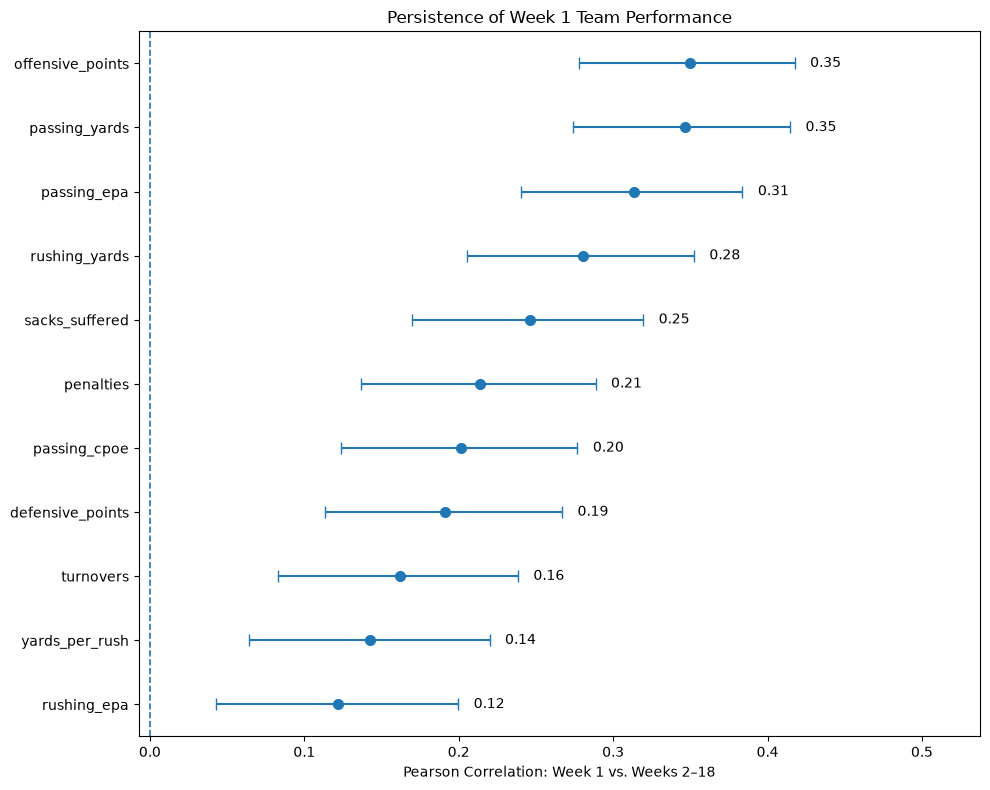

In [37]:
## Persistence of Week 1 Team Performance

plot_data = q3_results.sort_values(
    "Pearson r"
).copy()

plt.figure(figsize=(10, 8))

plt.errorbar(
    plot_data["Pearson r"],
    plot_data["Metric"],
    xerr=[
        plot_data["Pearson r"] - plot_data["Pearson CI Lower"],
        plot_data["Pearson CI Upper"] - plot_data["Pearson r"],
    ],
    fmt="o",
    markersize=7,
    capsize=4,
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.2,
)

for _, row in plot_data.iterrows():
    plt.text(
        row["Pearson CI Upper"] + 0.01,
        row["Metric"],
        f"{row['Pearson r']:.2f}",
        va="center",
    )

plt.xlabel(
    "Pearson Correlation: Week 1 vs. Weeks 2–18"
)
plt.ylabel("")
plt.title(
    "Persistence of Week 1 Team Performance"
)

plt.xlim(
    min(plot_data["Pearson CI Lower"]) - 0.05,
    max(plot_data["Pearson CI Upper"]) + 0.12,
)

plt.tight_layout()
plt.show()

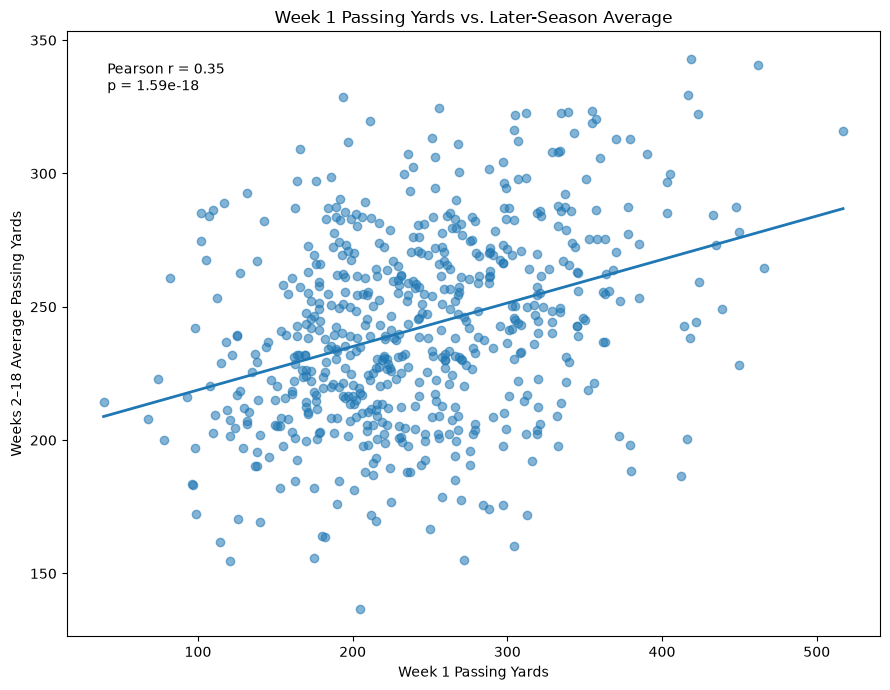

In [ ]:
## Week 1 passing yards vs. later-season passing yards

x = q3_analysis["passing_yards_week1"]
y = q3_analysis["passing_yards_later"]

r, p = pearsonr(x, y)

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    100,
)

y_line = slope * x_line + intercept

plt.figure(figsize=(9, 7))

plt.scatter(
    x,
    y,
    alpha=0.55,
)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
)

plt.text(
    0.05,
    0.95,
    f"Pearson r = {r:.2f}\np = {p:.4g}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.xlabel("Week 1 Passing Yards")
plt.ylabel("Weeks 2–18 Average Passing Yards")
plt.title("Week 1 Passing Yards vs. Later-Season Average")

plt.tight_layout()
plt.show()

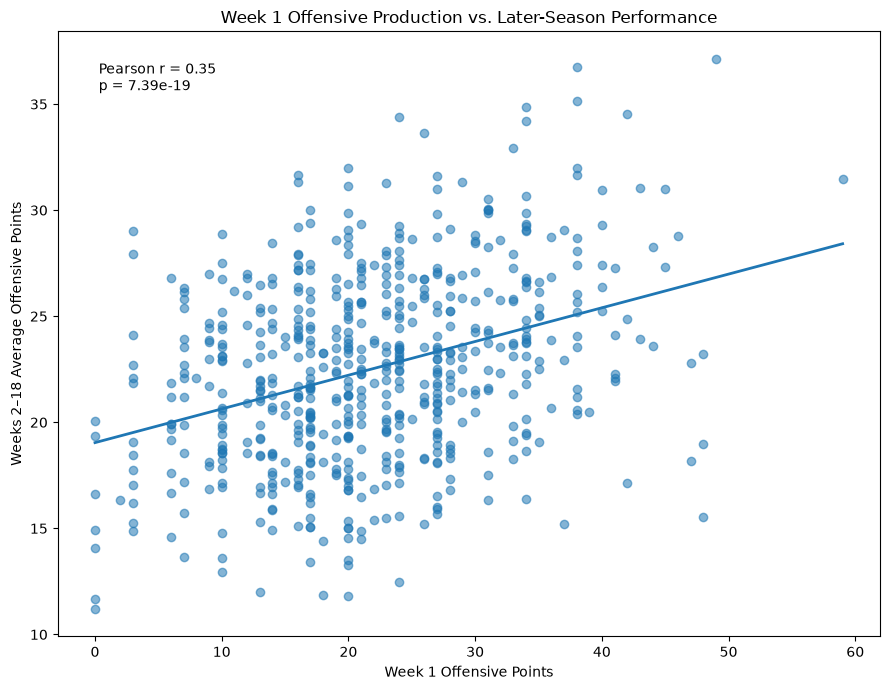

In [ ]:
## Week 1 offensive points vs. later-season offensive points

x = q3_analysis["offensive_points_week1"]
y = q3_analysis["offensive_points_later"]

r, p = pearsonr(x, y)

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    100,
)

y_line = slope * x_line + intercept

plt.figure(figsize=(9, 7))

plt.scatter(
    x,
    y,
    alpha=0.55,
)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
)

plt.text(
    0.05,
    0.95,
    f"Pearson r = {r:.2f}\np = {p:.4g}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.xlabel("Week 1 Offensive Points")
plt.ylabel("Weeks 2–18 Average Offensive Points")
plt.title("Week 1 Offensive Production vs. Later-Season Performance")

plt.tight_layout()
plt.show()

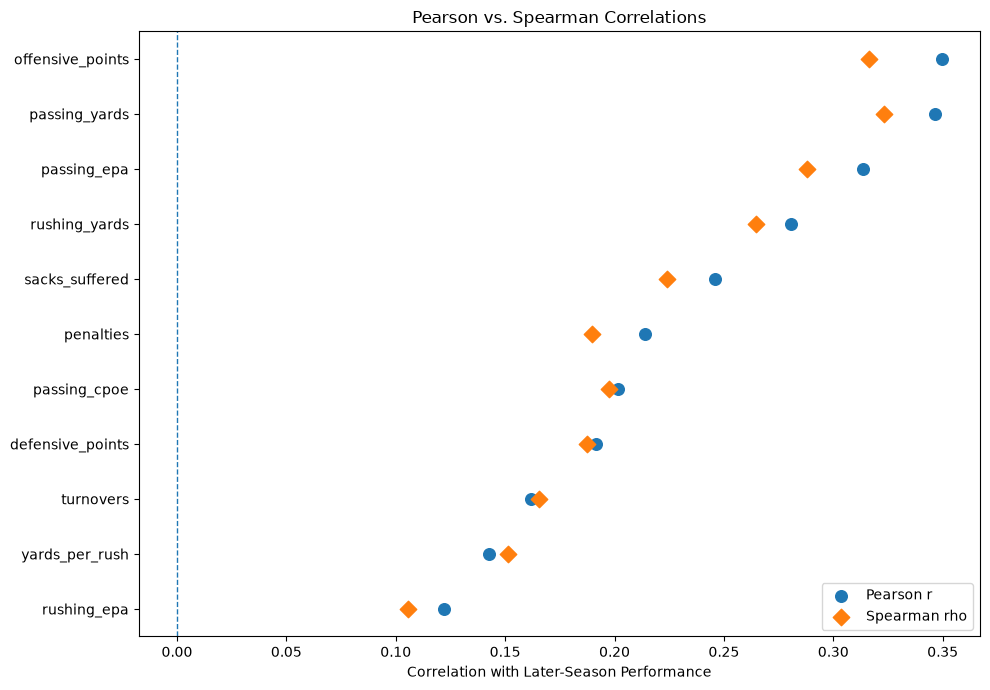

In [ ]:
## Pearson vs. Spearman correlations

correlation_plot = q3_results.sort_values(
    "Pearson r"
).copy()

y_positions = np.arange(
    len(correlation_plot)
)

plt.figure(figsize=(10, 7))

plt.scatter(
    correlation_plot["Pearson r"],
    y_positions,
    s=70,
    label="Pearson r",
)

plt.scatter(
    correlation_plot["Spearman rho"],
    y_positions,
    s=70,
    marker="D",
    label="Spearman rho",
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.yticks(
    y_positions,
    correlation_plot["Metric"]
)

plt.xlabel("Correlation with Later-Season Performance")
plt.ylabel("")
plt.title("Pearson vs. Spearman Correlations")

plt.legend()
plt.tight_layout()
plt.show()

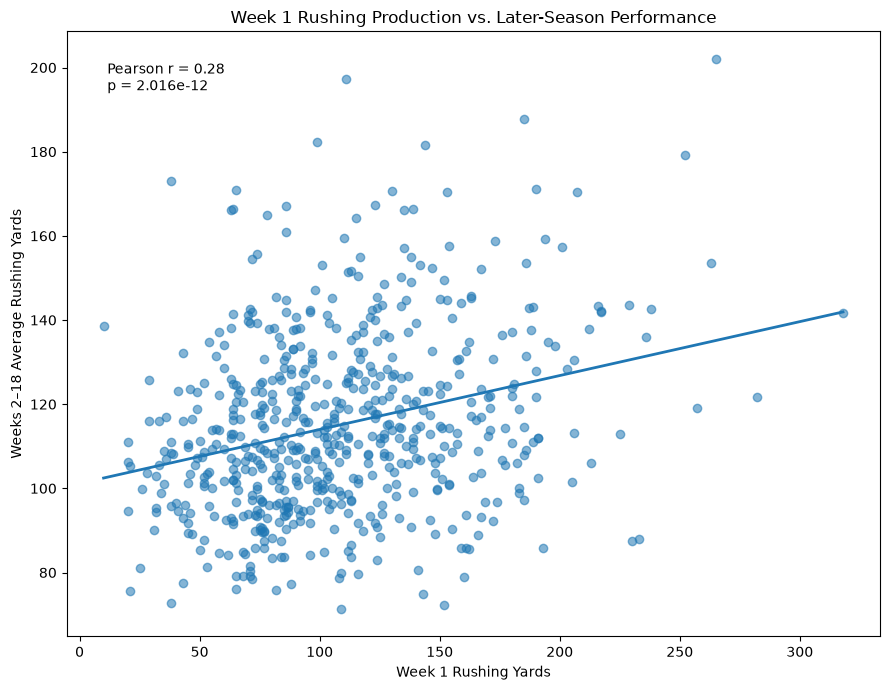

In [34]:
## Week 1 rushing yards vs. later-season rushing yards

x = q3_analysis["rushing_yards_week1"]
y = q3_analysis["rushing_yards_later"]

r, p = pearsonr(x, y)

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    100,
)

y_line = slope * x_line + intercept

plt.figure(figsize=(9, 7))

plt.scatter(
    x,
    y,
    alpha=0.55,
)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
)

plt.text(
    0.05,
    0.95,
    f"Pearson r = {r:.2f}\np = {p:.4g}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.xlabel("Week 1 Rushing Yards")
plt.ylabel("Weeks 2–18 Average Rushing Yards")
plt.title("Week 1 Rushing Production vs. Later-Season Performance")

plt.tight_layout()
plt.show()

## Q3 takeaway

Week 1 performance shows statistically significant positive relationships with later-season team performance across all 11 metrics after false discovery rate adjustment.

The strongest relationships are observed for **offensive points, passing yards, passing EPA, and rushing yards**.

The relationships are generally modest rather than extremely strong, indicating that Week 1 provides useful information about later performance but does not determine how a team will perform for the remainder of the season.

Overall, the results suggest that **production measures persist more strongly than efficiency measures**.


# Final Statistical Analysis Summary

### Q2 — Week 1 vs. later games
Week 1 differs most clearly in penalties and rushing production, with relatively small effect sizes. Passing production is especially stable.

### Q3 — Week 1 persistence
Week 1 team performance is positively associated with later-season performance across the measures tested, with the strongest persistence appearing in production-oriented metrics.

These results complement the upset analysis in Notebook 02 by examining whether Week 1 differs in underlying game characteristics and whether early team performance contains information about the rest of the season.
